In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import load_g09
import pyvinecopulib as pv
from scipy import stats
from scipy.stats import rankdata
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid

In [2]:
g09 = load_g09()

/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inp

In [3]:
def load_g09_waveswide_xys():
    g09 = load_g09()
    sel = (g09['g-i'] > 0.) * (g09['g-i'] < 2) * (g09['mag_Zt'] < 21.1)

    g09_valid = g09[sel]
    g09_valid = g09_valid[g09_valid['z_best'] < 0.2]
    g09_valid = g09_valid.dropna(subset=['P020_comb', 'g-i', 'z_best', 'mag_Zt'])

    g09_valid['TP'] = g09_valid['P020_comb'] > 0.14

    x_all = -g09_valid['mag_Zt'].to_numpy() + 21.1
    y_all = g09_valid['g-i'].to_numpy()
    xy_all = np.column_stack((x_all, y_all))

    xy_all_tp_mask = g09_valid['TP'].to_numpy()

    xy_fn = xy_all[~xy_all_tp_mask]

    return xy_all, xy_fn, xy_all_tp_mask

xy_all, xy_fn, xy_all_tp_mask = load_g09_waveswide_xys()

PI_FN = len(xy_fn) / len(xy_all)
print('PI FP:', PI_FN)

/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inp

PI FP: 0.05187452180566182


In [6]:
# ════════════════════════════════════════════════════════════════════════════════
# MIXTURE MODEL DEFINITIONS
# ════════════════════════════════════════════════════════════════════════════════

def linear_gauss(x, w, slope, intercept, mu, sigma):
    """Normalised linear-component + Gaussian mixture PDF."""
    linear = np.clip(slope * x + intercept, 0, None)
    norm_factor = np.trapezoid(linear, x)
    if norm_factor > 0:
        linear /= norm_factor
    gauss = stats.norm.pdf(x, mu, sigma)
    return w * linear + (1 - w) * gauss


def double_gauss(x, w, mu1, s1, mu2, s2):
    """Two-component Gaussian mixture PDF."""
    return w * stats.norm.pdf(x, mu1, s1) + (1 - w) * stats.norm.pdf(x, mu2, s2)


# ════════════════════════════════════════════════════════════════════════════════
# CDF UTILITIES
# ════════════════════════════════════════════════════════════════════════════════

def pdf_to_cdf(xr, pdf_vals):
    """Numerically integrate a PDF array to a normalised CDF."""
    cdf = cumulative_trapezoid(pdf_vals, xr, initial=0)
    cdf /= cdf[-1]
    return cdf


def cdf_transform(data, xr, cdf_vals):
    """Map data to uniform [0,1] via interpolation onto a fitted CDF."""
    return np.interp(data, xr, cdf_vals)


# ════════════════════════════════════════════════════════════════════════════════
# FITTERS  (one per distribution family)
# ════════════════════════════════════════════════════════════════════════════════

def fit_linear(data, n_bins=30):
    """
    Fit a decreasing linear PDF  f(x) = slope·x + intercept  to `data`.

    Returns
    -------
    u        : uniform [0,1] marginals
    xr       : evaluation grid
    pdf_vals : PDF evaluated on xr
    cdf_vals : CDF evaluated on xr
    params   : dict with slope, intercept, x_min, x_max
    """
    counts, edges = np.histogram(data, bins=n_bins, density=True)
    bc = (edges[:-1] + edges[1:]) / 2
    slope, intercept, *_ = stats.linregress(bc, counts)

    x_min, x_max = data.min(), data.max()
    C = -(0.5 * slope * x_min**2 + intercept * x_min)

    xr       = np.linspace(x_min, x_max, 10000)
    pdf_vals = np.clip(slope * xr + intercept, 0, None)
    cdf_vals = np.clip(0.5 * slope * xr**2 + intercept * xr + C, 0, 1)
    u        = np.interp(data, xr, cdf_vals)

    params = dict(slope=slope, intercept=intercept, x_min=x_min, x_max=x_max)
    return u, xr, pdf_vals, cdf_vals, params


def fit_linear_gauss(data, n_bins=30):
    """
    Fit a linear + Gaussian mixture PDF to `data`.

    Returns
    -------
    u        : uniform [0,1] marginals
    xr       : evaluation grid
    pdf_vals : PDF evaluated on xr
    cdf_vals : CDF evaluated on xr
    params   : dict with w, slope, intercept, mu, sigma
    """
    counts, edges = np.histogram(data, bins=n_bins, density=True)
    bc = (edges[:-1] + edges[1:]) / 2

    p0     = [0.5, -0.1, 1.0, data.mean(), data.std()]
    bounds = ([0, -10, -10, data.min(), 0.01],
              [1,  10,  10, data.max(), 10  ])

    popt, _ = curve_fit(linear_gauss, bc, counts, p0=p0,
                        bounds=bounds, maxfev=20_000)
    w, slope, intercept, mu, sigma = popt

    xr       = np.linspace(data.min(), data.max(), 10000)
    pdf_vals = linear_gauss(xr, *popt)
    cdf_vals = pdf_to_cdf(xr, pdf_vals)
    u        = cdf_transform(data, xr, cdf_vals)

    params = dict(w=w, slope=slope, intercept=intercept, mu=mu, sigma=sigma)
    return u, xr, pdf_vals, cdf_vals, params


def fit_double_gauss(data, n_bins=30):
    """
    Fit a two-component Gaussian mixture PDF to `data`.

    Returns
    -------
    u        : uniform [0,1] marginals
    xr       : evaluation grid
    pdf_vals : PDF evaluated on xr
    cdf_vals : CDF evaluated on xr
    params   : dict with w, mu1, s1, mu2, s2
    """
    counts, edges = np.histogram(data, bins=n_bins, density=True)
    bc = (edges[:-1] + edges[1:]) / 2

    p0     = [0.5, data.mean() - 0.5, data.std() * 0.5,
                   data.mean() + 0.5, data.std() * 0.5]
    bounds = ([0, -10, 0.01, -10, 0.01],
              [1,  10,    5,  10,    5])

    popt, _ = curve_fit(double_gauss, bc, counts, p0=p0,
                        bounds=bounds, maxfev=20_000)
    w, mu1, s1, mu2, s2 = popt

    xr       = np.linspace(data.min() - 0.5, data.max() + 0.5, 10000)
    pdf_vals = double_gauss(xr, *popt)
    cdf_vals = pdf_to_cdf(xr, pdf_vals)
    u        = cdf_transform(data, xr, cdf_vals)

    params = dict(w=w, mu1=mu1, s1=s1, mu2=mu2, s2=s2)
    return u, xr, pdf_vals, cdf_vals, params


def fit_single_gauss(data):
    """
    Fit a single Gaussian PDF to `data` via MLE.

    Returns
    -------
    u        : uniform [0,1] marginals
    xr       : evaluation grid
    pdf_vals : PDF evaluated on xr
    cdf_vals : CDF evaluated on xr
    params   : dict with mu, sigma
    """
    mu, sigma = stats.norm.fit(data)

    xr       = np.linspace(data.min() - 0.5, data.max() + 0.5, 10000)
    pdf_vals = stats.norm.pdf(xr, mu, sigma)
    cdf_vals = pdf_to_cdf(xr, pdf_vals)
    u        = cdf_transform(data, xr, cdf_vals)

    params = dict(mu=mu, sigma=sigma)
    return u, xr, pdf_vals, cdf_vals, params



x_all = xy_all[:, 0]
y_all = xy_all[:, 1]
x_fn = xy_fn[:, 0]
y_fn = xy_fn[:, 1]

def report_fit(label, family, params):
    """Print a one-line summary of a fitted distribution."""
    if family == "linear":
        print(f"{label:25s}  linear({params['slope']:.3f}x + {params['intercept']:.3f})")
    elif family == "linear_gauss":
        p = params
        print(f"{label:25s}  w={p['w']:.3f}  "
              f"linear({p['slope']:.3f}x + {p['intercept']:.3f})  "
              f"N({p['mu']:.3f}, {p['sigma']:.3f})")
    elif family == "double_gauss":
        p = params
        print(f"{label:25s}  w={p['w']:.3f}  "
              f"N({p['mu1']:.3f}, {p['s1']:.3f})  "
              f"N({p['mu2']:.3f}, {p['s2']:.3f})")
    elif family == "single_gauss":
        print(f"{label:25s}  N({params['mu']:.3f}, {params['sigma']:.3f})")
        

def fit_all_marginals(x_all, x_fn, y_all, y_fn):
    """
    Fit parametric marginal distributions to each variable/subset pair
    and return uniform [0,1] transforms alongside fit diagnostics.

    Parameters
    ----------
    x_all : array  –  magnitude for all objects
    x_fn  : array  –  magnitude for false-negative subset
    y_all : array  –  g−i colour for all objects
    y_fn  : array  –  g−i colour for false-negative subset

    Returns
    -------
    dict keyed by variable name, each containing
        'u'        – uniform marginals
        'xr'       – evaluation grid   (None for linear fit)
        'pdf_vals' – PDF on grid        (callable for linear fit)
        'cdf_vals' – CDF on grid        (callable for linear fit)
        'params'   – fitted parameters
    """
    results = {}

    # 1. x_all  →  linear PDF
    u, xr, pdf_vals, cdf_vals, params = fit_linear(x_all)
    report_fit("x_all", "linear", params)
    results["x_all"] = dict(u=u, xr=xr, pdf_vals=pdf_vals,
                            cdf_vals=cdf_vals, params=params)

    # 2. x_fn  →  linear + Gaussian mixture
    u, xr, pdf_vals, cdf_vals, params = fit_linear_gauss(x_fn)
    report_fit("x_fn", "linear_gauss", params)
    results["x_fn"] = dict(u=u, xr=xr, pdf_vals=pdf_vals,
                           cdf_vals=cdf_vals, params=params)

    # 3. y_all  →  double Gaussian
    u, xr, pdf_vals, cdf_vals, params = fit_double_gauss(y_all)
    report_fit("y_all", "double_gauss", params)
    results["y_all"] = dict(u=u, xr=xr, pdf_vals=pdf_vals,
                            cdf_vals=cdf_vals, params=params)

    # 4. y_fn  →  single Gaussian
    u, xr, pdf_vals, cdf_vals, params = fit_single_gauss(y_fn)
    report_fit("y_fn", "single_gauss", params)
    results["y_fn"] = dict(u=u, xr=xr, pdf_vals=pdf_vals,
                           cdf_vals=cdf_vals, params=params)

    return results

pdf_transformations = fit_all_marginals(x_all, x_fn, y_all, y_fn)

x_all                      linear(-0.074x + 0.390)
x_fn                       w=0.469  linear(-2.526x + 2.269)  N(1.029, 1.077)
y_all                      w=0.698  N(0.734, 0.210)  N(1.358, 0.214)
y_fn                       N(1.082, 0.330)


In [7]:
pdf_transformations['x_all']

{'u': array([0.28669682, 0.5608958 , 0.19285132, ..., 0.10268782, 0.06882675,
        0.14567202], shape=(6535,)),
 'xr': array([6.49740739e-05, 6.70602644e-04, 1.27623121e-03, ...,
        6.05453379e+00, 6.05513942e+00, 6.05574505e+00], shape=(10000,)),
 'pdf_vals': array([0.39014618, 0.39010117, 0.39005617, ..., 0.        , 0.        ,
        0.        ], shape=(10000,)),
 'cdf_vals': array([0.00000000e+00, 2.36270045e-04, 4.72512833e-04, ...,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00], shape=(10000,)),
 'params': {'slope': np.float64(-0.07431434943893975),
  'intercept': np.float64(0.3901510101376251),
  'x_min': np.float64(6.497407386518717e-05),
  'x_max': np.float64(6.055745048052449)}}

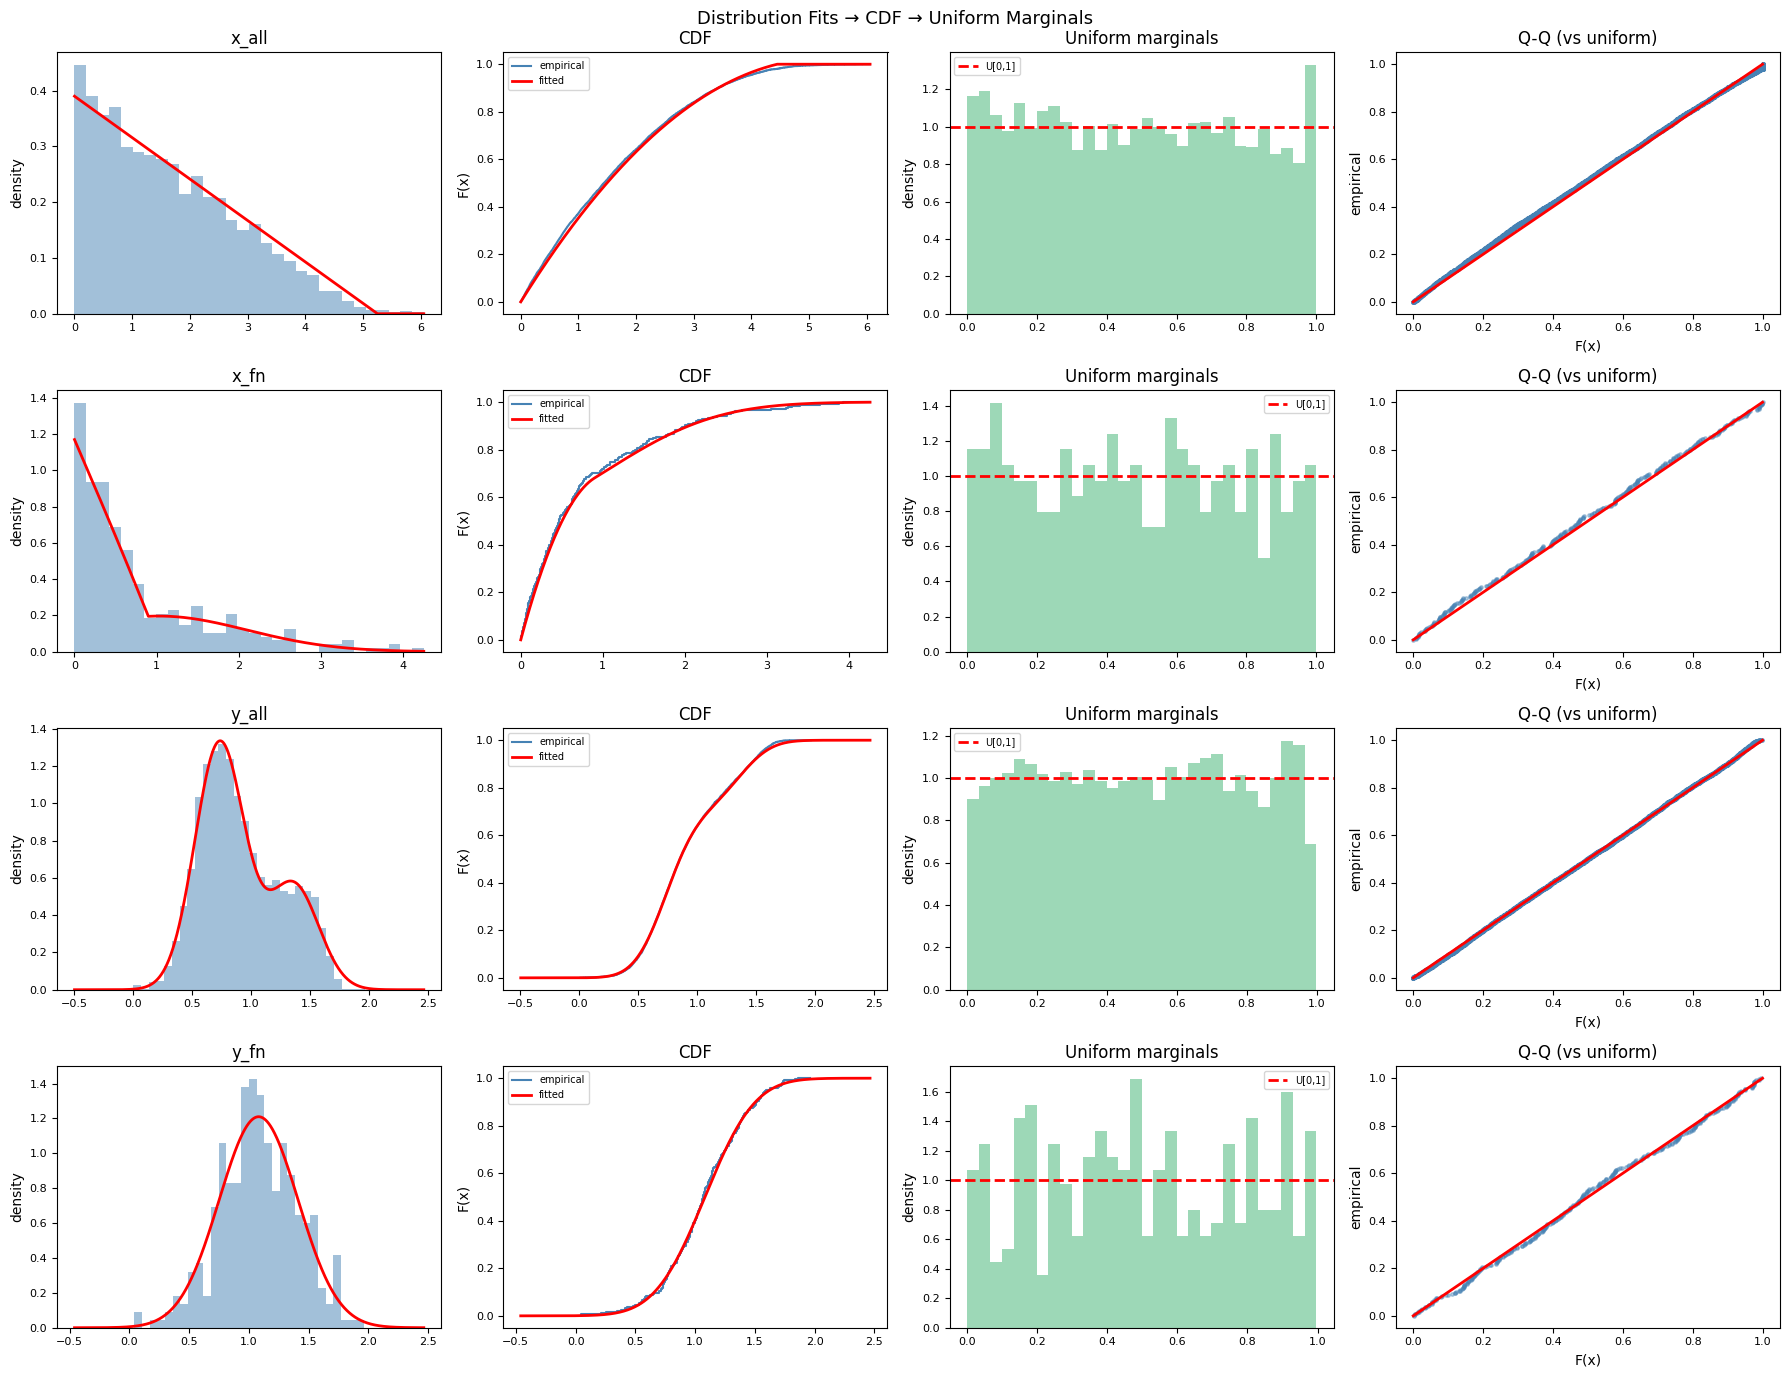

In [8]:


def plot_marginal_fits(results, data_map, save_path="all_fits_marginals.png"):
    """
    Plot fit diagnostics for each variable in `results`.

    Parameters
    ----------
    results  : dict returned by fit_all_marginals()
    data_map : dict mapping the same keys to the original raw data arrays,
               e.g. {"x_all": x_all, "x_fn": x_fn, "y_all": y_all, "y_fn": y_fn}
    save_path: file path for the saved figure
    """
    keys   = list(results.keys())
    n_rows = len(keys)

    fig, axs = plt.subplots(n_rows, 4, figsize=(18, 3.5 * n_rows))
    fig.suptitle("Distribution Fits → CDF → Uniform Marginals", fontsize=13)

    for row, key in enumerate(keys):
        res  = results[key]
        data = data_map[key]
        xr, pdf_vals, cdf_vals, u = res['xr'], res['pdf_vals'], res['cdf_vals'], res['u']

        _plot_fit        (axs[row, 0], data, xr, pdf_vals, key)
        _plot_cdf        (axs[row, 1], data, xr, cdf_vals)
        _plot_uniform    (axs[row, 2], u)
        _plot_qq_uniform (axs[row, 3], u)

    for ax in axs.flat:
        ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


def _plot_fit(ax, data, xr, pdf_vals, title):
    """Col 0: histogram of data overlaid with fitted PDF."""
    ax.hist(data, bins=30, density=True, alpha=0.5, color="steelblue")
    ax.plot(xr, pdf_vals, "r-", lw=2)
    ax.set(title=title, ylabel="density")


def _plot_cdf(ax, data, xr, cdf_vals):
    """Col 1: empirical step CDF vs fitted CDF."""
    xs = np.sort(data)
    empirical = np.arange(1, len(data) + 1) / len(data)
    ax.step(xs, empirical, color="steelblue", lw=1.5, label="empirical")
    ax.plot(xr, cdf_vals, "r-", lw=2, label="fitted")
    ax.set(title="CDF", ylabel="F(x)")
    ax.legend(fontsize=7)


def _plot_uniform(ax, u):
    """Col 2: histogram of uniform marginals — should be flat at 1."""
    ax.hist(u, bins=30, density=True, alpha=0.5, color="mediumseagreen")
    ax.axhline(1.0, color="r", lw=2, ls="--", label="U[0,1]")
    ax.set(title="Uniform marginals", ylabel="density")
    ax.legend(fontsize=7)


def _plot_qq_uniform(ax, u):
    """Col 3: Q-Q plot of uniform marginals vs theoretical U[0,1]."""
    ax.scatter(np.sort(u), np.linspace(0, 1, len(u)), s=6, alpha=0.4, color="steelblue")
    ax.plot([0, 1], [0, 1], "r-", lw=2)
    ax.set(title="Q-Q (vs uniform)", xlabel="F(x)", ylabel="empirical")

data_map    = {"x_all": x_all, "x_fn": x_fn, "y_all": y_all, "y_fn": y_fn}
plot_marginal_fits(pdf_transformations, data_map)

In [9]:
np.array(pdf_transformations['x_all']['u'])

uv_all = np.column_stack((np.array(pdf_transformations['x_all']['u']), np.array(pdf_transformations['y_all']['u'])))
uv_fn = np.column_stack((np.array(pdf_transformations['x_fn']['u']), np.array(pdf_transformations['y_fn']['u'])))

Text(0.5, 1.0, 'Uniform Marginals: u_mag vs u_gi')

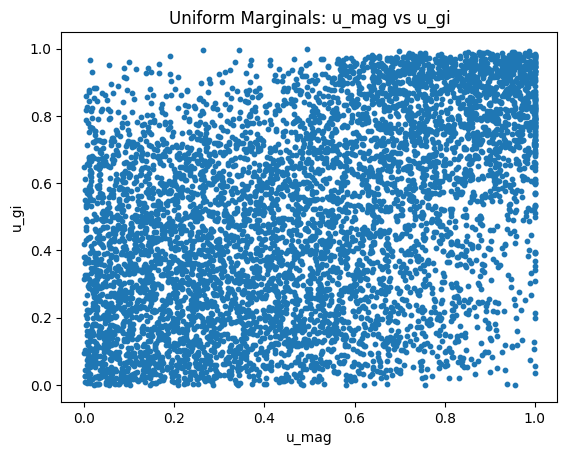

In [10]:
plt.scatter(uv_all[:, 0], uv_all[:, 1], s=10, label='All')
plt.xlabel('u_mag')
plt.ylabel('u_gi')
plt.title('Uniform Marginals: u_mag vs u_gi')

Text(0.5, 1.0, 'Uniform Marginals: u_mag vs u_gi')

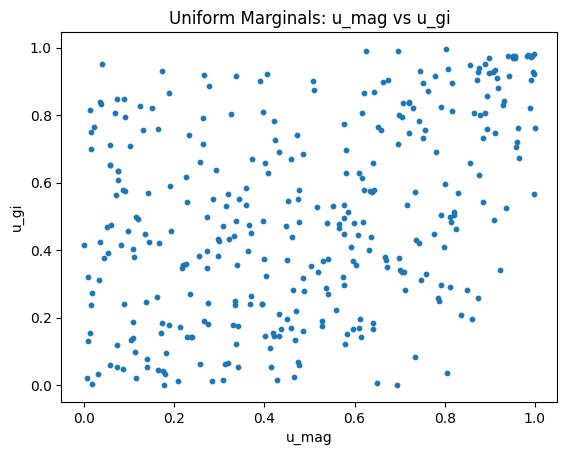

In [11]:
plt.scatter(uv_fn[:, 0], uv_fn[:, 1], s=10, label='All')
plt.xlabel('u_mag')
plt.ylabel('u_gi')
plt.title('Uniform Marginals: u_mag vs u_gi')

In [12]:
controls = pv.FitControlsBicop(family_set=pv.parametric)
cop_all = pv.Bicop.from_data(data=uv_all, controls=controls)
cop_fn = pv.Bicop.from_data(data=uv_fn, controls=controls)


In [13]:
print(cop_all, cop_fn)

<pyvinecopulib.Bicop> Bivariate copula: 
  family = BB8
  rotation = 0
  var_types = c,c
  parameters =  3.1
0.74
 <pyvinecopulib.Bicop> Bivariate copula: 
  family = BB8
  rotation = 0
  var_types = c,c
  parameters =  1.8
0.97



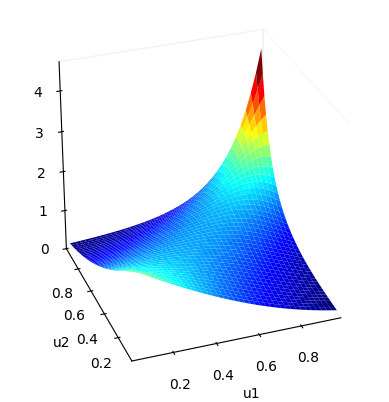

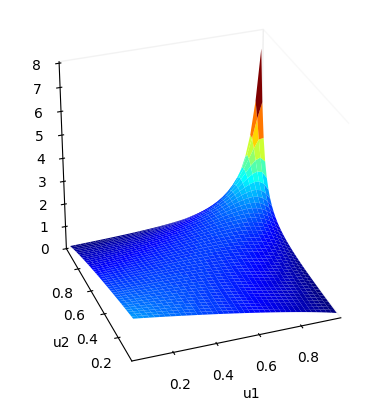

In [14]:
cop_all.plot()
cop_fn.plot()

In [15]:
samples_all = cop_all.simulate(6000)
samples_fn = cop_fn.simulate(300)

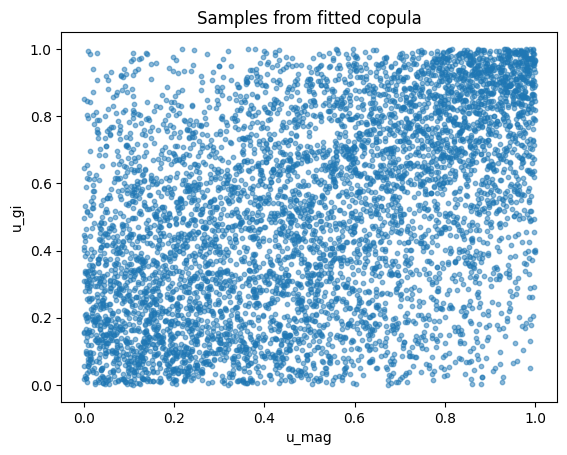

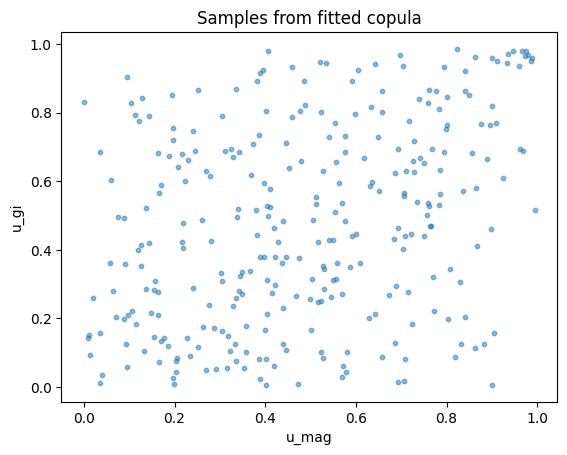

In [16]:
plt.scatter(samples_all[:, 0], samples_all[:, 1], s=10, alpha=0.5, label='All')
plt.xlabel('u_mag')
plt.ylabel('u_gi')
plt.title('Samples from fitted copula')
plt.show()
plt.scatter(samples_fn[:, 0], samples_fn[:, 1], s=10, alpha=0.5, label='FN')
plt.xlabel('u_mag')
plt.ylabel('u_gi')
plt.title('Samples from fitted copula')
plt.show()

In [18]:
# ════════════════════════════════════════════════════════════════════════════════
# INVERSE CDF  (uniform → real space)
# ════════════════════════════════════════════════════════════════════════════════

def inverse_cdf_numerical(u, xr, cdf_vals):
    """Map u in [0,1] back to x via interpolation of the numerical CDF."""
    return np.interp(np.asarray(u), cdf_vals, xr)


def inverse_cdf_linear(u, params):
    """
    Analytic inverse of F(x) = 0.5*slope*x^2 + intercept*x + C.
    Solves the quadratic for x given u in [0,1].
    """
    slope     = params['slope']
    intercept = params['intercept']
    x_min     = params['x_min']
    x_max     = params['x_max']
    C         = -(0.5 * slope * x_min**2 + intercept * x_min)

    u = np.asarray(u)
    a_coef = 0.5 * slope
    b_coef = intercept
    c_coef = C - u

    if abs(a_coef) < 1e-12:           # degenerate: nearly flat, linear solve
        return np.clip(-c_coef / b_coef, x_min, x_max)

    discriminant = np.clip(b_coef**2 - 4 * a_coef * c_coef, 0, None)
    x1 = (-b_coef + np.sqrt(discriminant)) / (2 * a_coef)
    x2 = (-b_coef - np.sqrt(discriminant)) / (2 * a_coef)
    candidates = np.where(
        (x1 >= x_min - 1e-6) & (x1 <= x_max + 1e-6), x1, x2
    )
    return np.clip(candidates, x_min, x_max)


def inverse_cdf_single_gauss(u, params):
    """Analytic inverse (PPF) of a single Gaussian."""
    return stats.norm.ppf(np.asarray(u), loc=params['mu'], scale=params['sigma'])


def invert_cdf(u, key, pdf_transformations):
    """
    Dispatch inverse CDF for any key in pdf_transformations.
    Uses analytic inverse where available, numerical otherwise.
    """
    res = pdf_transformations[key]
    if key == 'x_all':
        return inverse_cdf_linear(u, res['params'])
    elif key == 'y_fn':
        return inverse_cdf_single_gauss(u, res['params'])
    else:
        return inverse_cdf_numerical(u, res['xr'], res['cdf_vals'])


# ════════════════════════════════════════════════════════════════════════════════
# FORWARD CDF  (real space → uniform [0,1])
# ════════════════════════════════════════════════════════════════════════════════

def forward_cdf_linear(x, params):
    """Analytic CDF for the linear fit."""
    slope     = params['slope']
    intercept = params['intercept']
    x_min     = params['x_min']
    C         = -(0.5 * slope * x_min**2 + intercept * x_min)
    return np.clip(0.5 * slope * x**2 + intercept * x + C, 0, 1)


def forward_cdf_numerical(x, xr, cdf_vals):
    """Map x in real space to u in [0,1] via interpolation of the numerical CDF."""
    return np.interp(np.asarray(x), xr, cdf_vals)


def forward_cdf_single_gauss(x, params):
    """Analytic CDF of a single Gaussian."""
    return stats.norm.cdf(np.asarray(x), loc=params['mu'], scale=params['sigma'])


def forward_cdf(x, key, pdf_transformations):
    """
    Dispatch forward CDF for any key in pdf_transformations.
    Uses analytic CDF where available, numerical otherwise.
    """
    res = pdf_transformations[key]
    if key == 'x_all':
        return forward_cdf_linear(x, res['params'])
    elif key == 'y_fn':
        return forward_cdf_single_gauss(x, res['params'])
    else:
        return forward_cdf_numerical(x, res['xr'], res['cdf_vals'])


# ════════════════════════════════════════════════════════════════════════════════
# PDF  (density evaluation)
# ════════════════════════════════════════════════════════════════════════════════

def density_numerical(x, xr, pdf_vals):
    """Interpolate density at x from a precomputed PDF array."""
    return np.interp(np.asarray(x), xr, pdf_vals, left=0, right=0)


def density_linear(x, params):
    """Analytic linear PDF."""
    return np.clip(params['slope'] * np.asarray(x) + params['intercept'], 0, None)


def density_single_gauss(x, params):
    """Analytic single Gaussian PDF."""
    return stats.norm.pdf(np.asarray(x), loc=params['mu'], scale=params['sigma'])


def density(x, key, pdf_transformations):
    """
    Dispatch PDF evaluation for any key in pdf_transformations.
    Uses analytic PDF where available, numerical otherwise.
    """
    res = pdf_transformations[key]
    if key == 'x_all':
        return density_linear(x, res['params'])
    elif key == 'y_fn':
        return density_single_gauss(x, res['params'])
    else:
        return density_numerical(x, res['xr'], res['pdf_vals'])
    

def empirical_cdf(x):
    """Map data to uniform [0,1] via empirical CDF (rank-based)."""
    return rankdata(np.asarray(x)) / (len(x) + 1)


def transform_to_g09(xy, pdf_transformations):
    """
    Transform a new (x, y) dataset into the g09 marginal space.

    Applies an empirical CDF to each marginal of `xy`, then maps
    through the inverse CDFs of x_all (linear) and y_all (double Gaussian).

    Parameters
    ----------
    xy      : array of shape (n, 2)
    pdf_transformations : dict returned by fit_all_marginals()

    Returns
    -------
    array of shape (n, 2) in the g09 marginal space
    """
    x, y = xy[:, 0], xy[:, 1]

    u = empirical_cdf(x)
    v = empirical_cdf(y)

    x_transformed = invert_cdf(u, 'x_all', pdf_transformations)
    y_transformed = invert_cdf(v, 'y_all', pdf_transformations)

    return np.column_stack([x_transformed, y_transformed])

In [20]:
def get_completeness(xy_input, copula_all, copula_fn, pi_fn, pdf_transformations):
    """Compute completeness at xy_input by comparing PDFs from copula_all vs copula_fn.
    mag all and gi are input features, copula_all and copula_fn are the fitted copulas for the full vs FN (False Negative) subsets."""

    xy_renormed = transform_to_g09(xy_input, pdf_transformations)
    
    u_input_all = forward_cdf(xy_input[:,0], 'x_all', pdf_transformations)
    v_input_all = forward_cdf(xy_input[:,1], 'y_all', pdf_transformations)


    u_input_fn = forward_cdf(xy_input[:,0], 'x_fn', pdf_transformations)
    v_input_fn = forward_cdf(xy_input[:,1], 'y_fn', pdf_transformations)

    

    uv_input_all = np.column_stack((u_input_all, v_input_all))
    uv_input_fn = np.column_stack((u_input_fn, v_input_fn))

    u_all = copula_all.pdf(uv_input_all)
    u_fn = copula_fn.pdf(uv_input_fn)

    den_x_all = density(xy_renormed[:, 0], 'x_all', pdf_transformations)
    den_x_fn = density(xy_renormed[:, 0], 'x_fn', pdf_transformations)

    den_y_all = density(xy_renormed[:, 1], 'y_all', pdf_transformations)
    den_y_fn = density(xy_renormed[:, 1], 'y_fn', pdf_transformations)

    den_fn = u_fn * den_x_fn * den_y_fn
    den_all = u_all * den_x_all * den_y_all
    # Compute densities at the recovered points

    completeness = 1 - den_fn * pi_fn  / (den_all + 1e-12)
    # Clip completeness to [0,1]
    completeness = np.clip(completeness, 0, 1)
    return completeness

In [21]:
comp = get_completeness(xy_all, cop_all, cop_fn, PI_FN, pdf_transformations)

In [22]:
comp

array([0.99230192, 0.99381581, 0.98074004, ..., 0.92482655, 0.95406392,
       0.96596628], shape=(6535,))

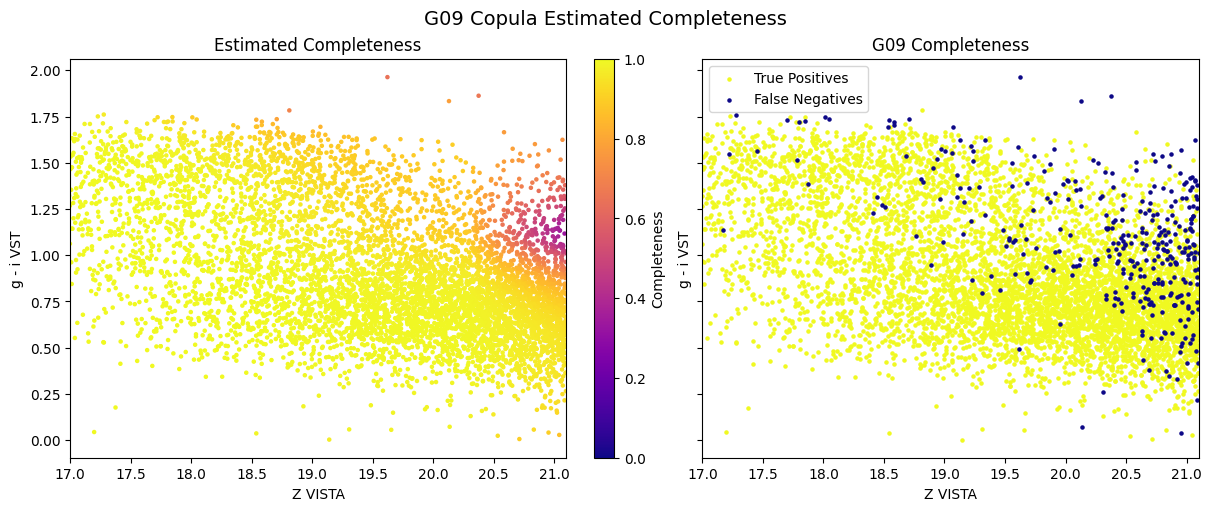

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True, constrained_layout=True)

sc0 = ax[0].scatter(-xy_all[:, 0] + 21.1, xy_all[:, 1], c=comp, s=5, cmap='plasma', vmin=0, vmax=1)
fig.colorbar(sc0, ax=ax[0], label='Completeness')
ax[0].set_title('Estimated Completeness')
ax[0].set_xlabel('Z VISTA')
ax[0].set_ylabel('g - i VST')
ax[0].set_xlim(17, 21.1)

tps = xy_all[xy_all_tp_mask == 1]
fns = xy_all[xy_all_tp_mask == 0]

ax[1].scatter(-tps[:, 0] + 21.1, tps[:, 1], s=5, color='#F0F921', label='True Positives')
ax[1].scatter(-fns[:, 0] + 21.1, fns[:, 1], s=5, color='#0D0887', label='False Negatives')
ax[1].set_title('G09 Completeness')
ax[1].set_xlabel('Z VISTA')
ax[1].set_ylabel('g - i VST')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].legend()
fig.suptitle("G09 Copula Estimated Completeness", fontsize=14)
plt.savefig("completeness_map.png", dpi=150)
plt.show()

In [25]:
print(1 - sum(comp) / len(comp))
print(PI_FN)

0.049715818209633444
0.05187452180566182


In [26]:
sharks = pd.read_parquet('/Users/sp624AA/Downloads/group_finding_mocks/galaxies_shark.parquet')

In [27]:
for i in sharks.columns:
    print(i)

id_galaxy_sky
ra
dec
redshift_observed
redshift_cosmological
inclination
position_angle
mass_stellar_disk
mass_stellar_bulge
mass_stellar_total
mass_virial_hosthalo
mass_virial_subhalo
cnfw_subhalo
sfr_disk
sfr_burst
sfr_total
radius_disk_apparent
radius_bulge_apparent
radius_disk_instrinsic
id_group_sky
subvolume
vel_peculiar_x
vel_peculiar_y
vel_peculiar_z
vel_peculiar_radial
mag_FUV_GALEX
mag_NUV_GALEX
mag_u_SDSS
mag_g_SDSS
mag_r_SDSS
mag_i_SDSS
mag_z_SDSS
mag_u_VST
mag_g_VST
mag_r_VST
mag_i_VST
mag_Z_VISTA
mag_Y_VISTA
mag_J_VISTA
mag_H_VISTA
mag_K_VISTA
mag_W1_WISE
mag_I1_Spitzer
mag_I2_Spitzer
mag_W2_WISE
mag_I3_Spitzer
mag_I4_Spitzer
mag_W3_WISE
mag_W4_WISE
mag_M24_Spitzer
mag_M70_Spitzer
mag_P70_Herschel
mag_P100_Herschel
mag_P160_Herschel
mag_S250_Herschel
mag_S350_Herschel
mag_S450_JCMT
mag_S500_Herschel
mag_S850_JCMT
mag_Band_ionising_photons
mag_Band9_ALMA
mag_Band8_ALMA
mag_Band7_ALMA
mag_Band6_ALMA
mag_Band5_ALMA
mag_Band4_ALMA
mag_Band3_ALMA
mag_BandX_VLA
mag_BandC_VLA
ma

In [28]:
cols_to_keep = ['redshift_observed', 'mag_g_VST', 'mag_i_VST', 'mag_Z_VISTA', 'mass_stellar_total', 'id_fof', 'id_group_sky', 'mag_abs_Z_VISTA']

sharks = sharks[cols_to_keep]

In [29]:
sharks['g-i'] = sharks['mag_g_VST'] - sharks['mag_i_VST']

In [30]:
sel_sharks = (sharks['mag_Z_VISTA'] < 21.1) * (sharks['redshift_observed'] < 0.2) * (sharks['mass_stellar_total'] > 8)

In [31]:
wide_sharks = sharks[sel_sharks].reset_index(drop=True)

In [32]:
xy_sharks = np.column_stack([-wide_sharks['mag_Z_VISTA'] + 21.1, wide_sharks['g-i']])

In [33]:
comp_sharks = get_completeness(xy_sharks, cop_all, cop_fn, PI_FN, pdf_transformations)

In [34]:
# generate boolean array for a subsample of sharks..
subsample_sharks_inds = wide_sharks.sample(10000, random_state=42).index
subsample_sharks = wide_sharks.index.isin(subsample_sharks_inds)

In [35]:
subsample_sharks

array([False, False, False, ..., False, False, False], shape=(876593,))

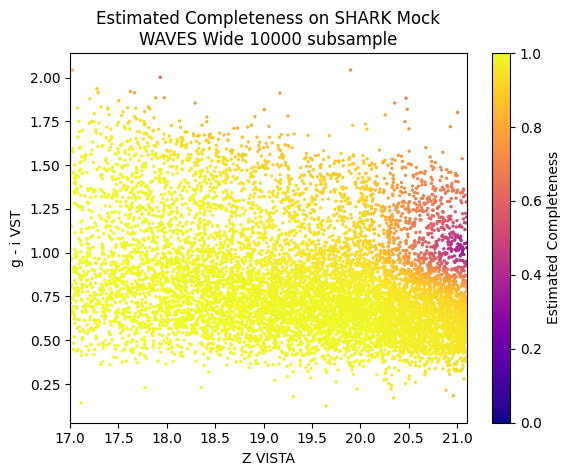

In [36]:
plt.scatter(wide_sharks['mag_Z_VISTA'][subsample_sharks], wide_sharks['g-i'][subsample_sharks], c=comp_sharks[subsample_sharks], s = 2, cmap='plasma', vmin=0, vmax=1)
plt.colorbar(label='Estimated Completeness')
plt.xlabel('Z VISTA')
plt.ylabel('g - i VST')
plt.xlim(17, 21.1)
plt.title(f'Estimated Completeness on SHARK Mock\nWAVES Wide 10000 subsample')
plt.savefig("completeness_map_shark.png", dpi=150)  

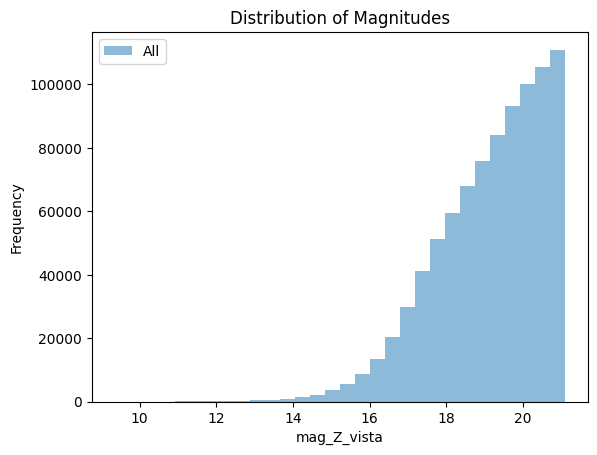

In [37]:
plt.hist(wide_sharks['mag_Z_VISTA'], bins=30, alpha=0.5, label='All')
plt.xlabel('mag_Z_vista')
plt.ylabel('Frequency')
plt.title('Distribution of Magnitudes')
plt.legend()
plt.show()

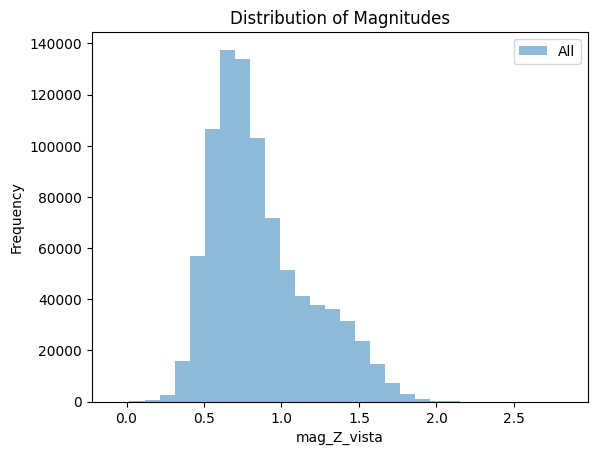

In [38]:
plt.hist(wide_sharks['g-i'], bins=30, alpha=0.5, label='All')
plt.xlabel('mag_Z_vista')
plt.ylabel('Frequency')
plt.title('Distribution of Magnitudes')
plt.legend()
plt.show()

In [39]:
sum(comp_sharks) / len(comp_sharks)

np.float64(0.9521253058055985)

In [40]:
wide_sharks['photoz_completeness'] = comp_sharks

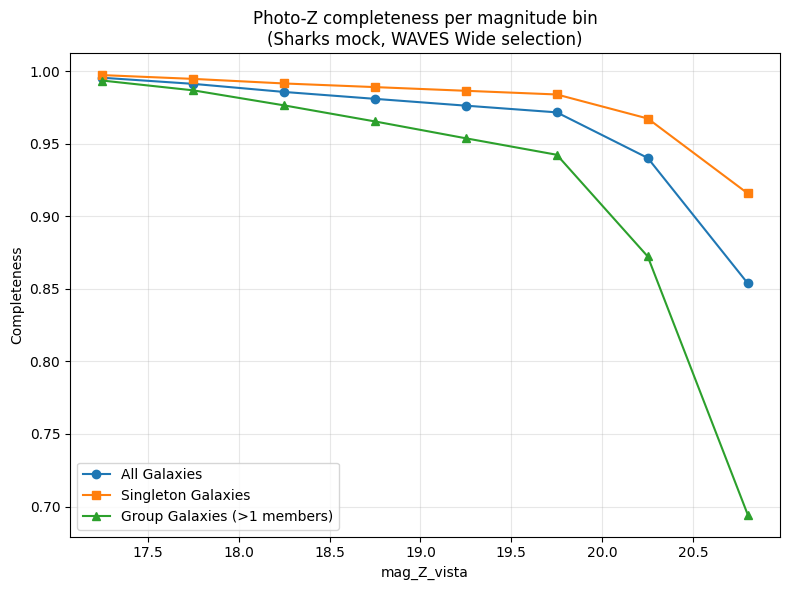

In [41]:
# --- 1. Magnitude bins ---
bins = np.array([17, 17.5,18, 18.5, 19, 19.5, 20, 20.5, 21.1])
bin_centers = 0.5 * (bins[:-1] + bins[1:])
wide_sharks['mag_bin'] = pd.cut(wide_sharks['mag_Z_VISTA'], bins=bins, include_lowest=True)

# --- 2. Group sizes ---
group_sizes = wide_sharks[wide_sharks['id_fof'] != -1].groupby('id_fof').size()
wide_sharks['group_size'] = wide_sharks['id_fof'].map(group_sizes)
wide_sharks.loc[wide_sharks['id_fof'] == -1, 'group_size'] = 1  # field = size 1

# Categories
wide_sharks['category'] = 'multi'
wide_sharks.loc[wide_sharks['group_size'] == 1, 'category'] = 'single'

# --- 3. Define estimator: sum(completeness) / N ---
def completeness_estimator(x):
    return x.sum() / x.count()

# Compute per bin
mean_all = wide_sharks.groupby('mag_bin')['photoz_completeness'].apply(completeness_estimator)

mean_single = wide_sharks[wide_sharks['category'] == 'single'] \
    .groupby('mag_bin')['photoz_completeness'].apply(completeness_estimator)

mean_multi = wide_sharks[wide_sharks['category'] == 'multi'] \
    .groupby('mag_bin')['photoz_completeness'].apply(completeness_estimator)

# --- 4. Plot ---
plt.figure(figsize=(8,6))

plt.plot(bin_centers, mean_all.values, marker='o', label='All Galaxies')
plt.plot(bin_centers, mean_single.values, marker='s', label='Singleton Galaxies')
plt.plot(bin_centers, mean_multi.values, marker='^', label='Group Galaxies (>1 members)')

plt.title('Photo-Z completeness per magnitude bin\n(Sharks mock, WAVES Wide selection)')
plt.xlabel('mag_Z_vista')
plt.ylabel('Completeness')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("completeness_vs_mag_shark.png", dpi=150)
plt.show()

In [42]:
# --- Group sizes ---
group_sizes = wide_sharks[wide_sharks['id_fof'] != -1].groupby('id_fof').size()
wide_sharks['group_size'] = wide_sharks['id_fof'].map(group_sizes)
wide_sharks.loc[wide_sharks['id_fof'] == -1, 'group_size'] = 1  # field = size 1

# Define masks
mask_single = wide_sharks['group_size'] == 1        # field + 1-member groups
mask_multi  = wide_sharks['group_size'] > 1         # real groups

# --- Completeness estimator: sum / N ---
def completeness(x):
    return x.sum() / x.count()

# --- Compute totals ---
comp_all    = completeness(wide_sharks['photoz_completeness'])
comp_single = completeness(wide_sharks.loc[mask_single, 'photoz_completeness'])
comp_multi  = completeness(wide_sharks.loc[mask_multi,  'photoz_completeness'])

print("All sample:", comp_all)
print("No groups (field + 1-member):", comp_single)
print("Groups (>1 members):", comp_multi)

All sample: 0.9521253058055835
No groups (field + 1-member): 0.9702154271767245
Groups (>1 members): 0.9189048954456214


In [43]:
# --- Group sizes ---
max_mag_lim = 20.8
wide_sharks_lim = wide_sharks[wide_sharks['mag_Z_VISTA'] < max_mag_lim].copy()

group_sizes = wide_sharks_lim[wide_sharks_lim['id_fof'] != -1].groupby('id_fof').size()
wide_sharks_lim['group_size'] = wide_sharks_lim['id_fof'].map(group_sizes)
wide_sharks_lim.loc[wide_sharks_lim['id_fof'] == -1, 'group_size'] = 1  # field = size 1

# Define masks
mask_single = wide_sharks_lim['group_size'] == 1        # field + 1-member groups
mask_multi  = wide_sharks_lim['group_size'] > 1         # real groups

# --- Completeness estimator: sum / N ---
def completeness(x):
    return x.sum() / x.count()

# --- Compute totals ---
comp_all    = completeness(wide_sharks_lim['photoz_completeness'])
comp_single = completeness(wide_sharks_lim.loc[mask_single, 'photoz_completeness'])
comp_multi  = completeness(wide_sharks_lim.loc[mask_multi,  'photoz_completeness'])

print("All sample:", comp_all)
print("No groups (field + 1-member):", comp_single)
print("Groups (>1 members):", comp_multi)

All sample: 0.9652049938807362
No groups (field + 1-member): 0.9787545019267537
Groups (>1 members): 0.9403659268442183


In [82]:
def transform_to_empirical(xy_input, xy_original):
    def empirical_cdf_transform(values, reference):
        ref_sorted = np.sort(reference)
        probs = np.arange(1, len(reference) + 1) / (len(reference) + 1)
        # Forward: map input values to CDF probabilities using reference distribution
        u = np.interp(values, ref_sorted, probs)
        # Inverse: map those probabilities back to the reference domain (quantile transform)
        x_transformed = np.interp(u, probs, ref_sorted)
        return x_transformed

    x = empirical_cdf_transform(xy_input[:, 0], xy_original[:, 0])
    y = empirical_cdf_transform(xy_input[:, 1], xy_original[:, 1])
    return np.column_stack([x, y])

In [83]:
transform_to_empirical(xy_sharks[subsample_sharks] , xy_all)

array([[5.57471275, 1.24665451],
       [1.86280441, 0.62006569],
       [2.89986229, 1.60024834],
       ...,
       [0.83750916, 0.61404419],
       [1.83482933, 0.75962639],
       [1.49704361, 0.75352287]], shape=(10000, 2))

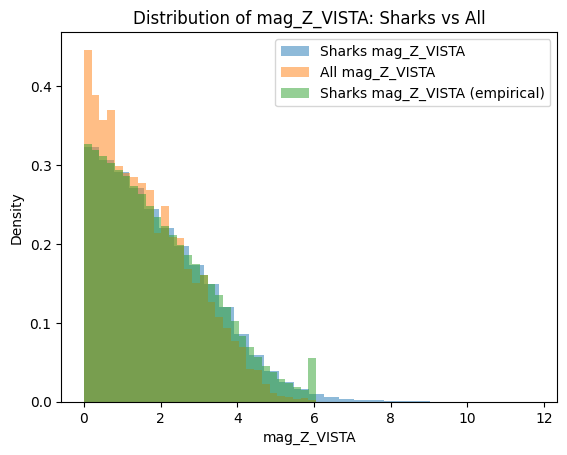

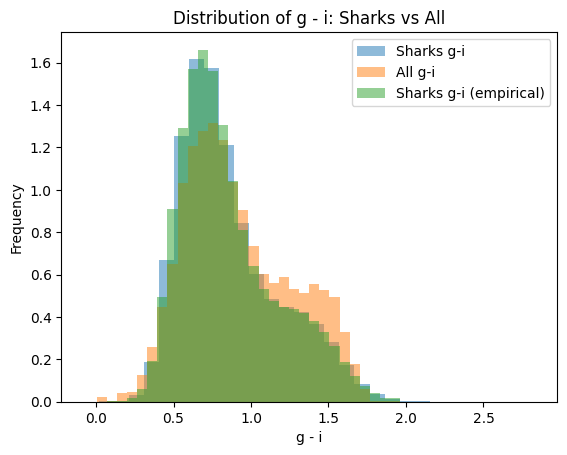

In [84]:
plt.hist(xy_sharks[:, 0], bins=30, alpha=0.5, label='Sharks mag_Z_VISTA', density=True)
plt.hist(xy_all[:, 0], bins=30, alpha=0.5, label='All mag_Z_VISTA', density=True)
plt.hist(transform_to_empirical(xy_sharks, xy_all)[:, 0], bins=30, alpha=0.5, label='Sharks mag_Z_VISTA (empirical)', density=True)
plt.xlabel('mag_Z_VISTA')
plt.ylabel('Density')
plt.title('Distribution of mag_Z_VISTA: Sharks vs All')
plt.legend()
plt.show()
plt.hist(xy_sharks[:, 1], bins=30, alpha=0.5, label='Sharks g-i', density=True)
plt.hist(xy_all[:, 1], bins=30, alpha=0.5, label='All g-i', density=True)
plt.hist(transform_to_empirical(xy_sharks, xy_all)[:, 1], bins=30, alpha=0.5, label='Sharks g-i (empirical)', density=True)
plt.xlabel('g - i')
plt.ylabel('Frequency')
plt.title('Distribution of g - i: Sharks vs All')
plt.legend()

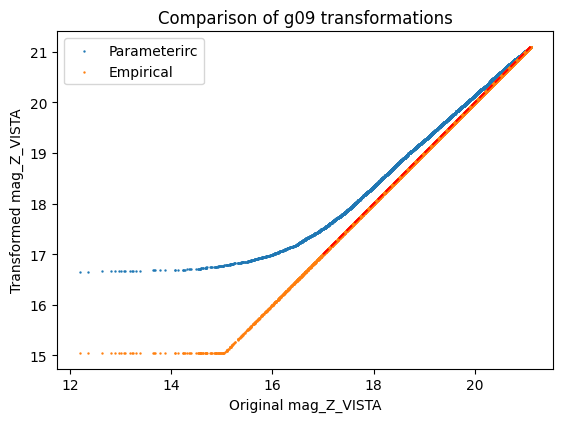

In [86]:
# choose 10000 datapoints from xy_sharks for visualization
sampled_xy_shark = xy_sharks[subsample_sharks]  

plt.scatter(21.1-sampled_xy_shark[:,0], 21.1- transform_to_g09(sampled_xy_shark, pdf_transformations)[:,0], s = 0.5, label='Parameterirc')
plt.scatter(21.1-sampled_xy_shark[:,0], 21.1- transform_to_empirical(sampled_xy_shark, xy_all)[:,0], s = 0.5, label='Empirical')
plt.xlabel('Original mag_Z_VISTA')
plt.ylabel('Transformed mag_Z_VISTA')
plt.title('Comparison of g09 transformations')
plt.legend()
plt.plot([17, 21.1], [17, 21.1], 'r--')
plt.gca().set_aspect('equal', adjustable='box')

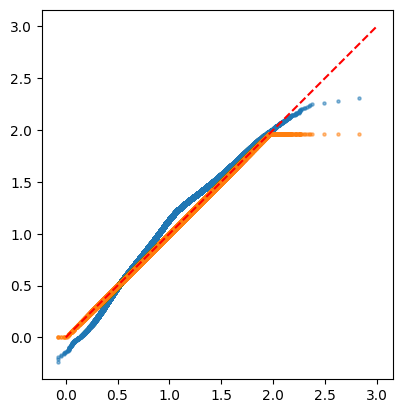

In [87]:
plt.scatter(xy_sharks[:,1], transform_to_g09(xy_sharks, pdf_transformations)[:,1], s=5, alpha=0.5)
plt.scatter(xy_sharks[:,1], transform_to_empirical(xy_sharks, xy_all)[:,1], s=5, alpha=0.5)
plt.plot([0, 3], [0, 3], 'r--')
plt.gca().set_aspect('equal', adjustable='box')

In [ ]:
# and so the best comparison is looking at the completeness between the empirical and the parameteric transformations. 
comp_empirical = get_completeness(transform_to_empirical(xy_sharks, xy_all), cop_all, cop_fn, PI_FN, pdf_transformations)
plt.scatter(xy_sharks[:,0], comp_sharks, s=5, alpha=0.5, label='Parametric')
plt.scatter(xy_sharks[:,0], comp_empirical, s=5, alpha=
5, label='Empirical')
plt.xlabel('mag_Z_VISTA')
plt.ylabel('Estimated Completeness')
plt.title('Completeness vs mag_Z_VISTA: Parametric vs Empirical')
plt.legend()
